In [6]:
# investigate the attributes of previews
from database.db import supabase
from database.types import PreviewComparisonRPC

In [4]:
# get the most recent 500 movies
movies = supabase.table("movie").select("*").order("release_date", desc=True).limit(500).execute()

In [20]:
previews: list[PreviewComparisonRPC] = supabase.rpc("preview_comparison").execute().data

previews = [p for p in previews if p["first_day_revenue"] is not None]

Text(0.5, 1.0, 'Percent of Recent 500 Movies with Previews')

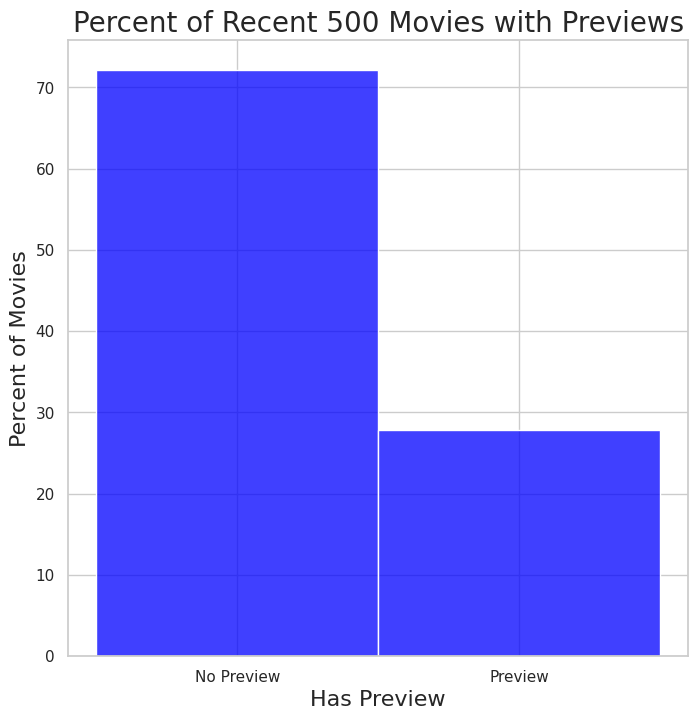

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# create a plot of the percent of recent movies that have previews
preview_ids = [preview["return_id"] for preview in previews]

movies_with_previews = [movie for movie in movies.data if movie["id"] in preview_ids]

plt.figure(figsize=(8, 8))

# make a bar plot of the percent of recent movies that have previews
sns.histplot(
    [1 if movie["id"] in preview_ids else 0 for movie in movies.data],
    bins=2,
    discrete=True,
    stat="percent",
    color="blue",
)

plt.xticks([0, 1], ["No Preview", "Preview"])
plt.xlabel("Has Preview", fontsize=16)
plt.ylabel("Percent of Movies", fontsize=16)
plt.title("Percent of Recent 500 Movies with Previews", fontsize=20)


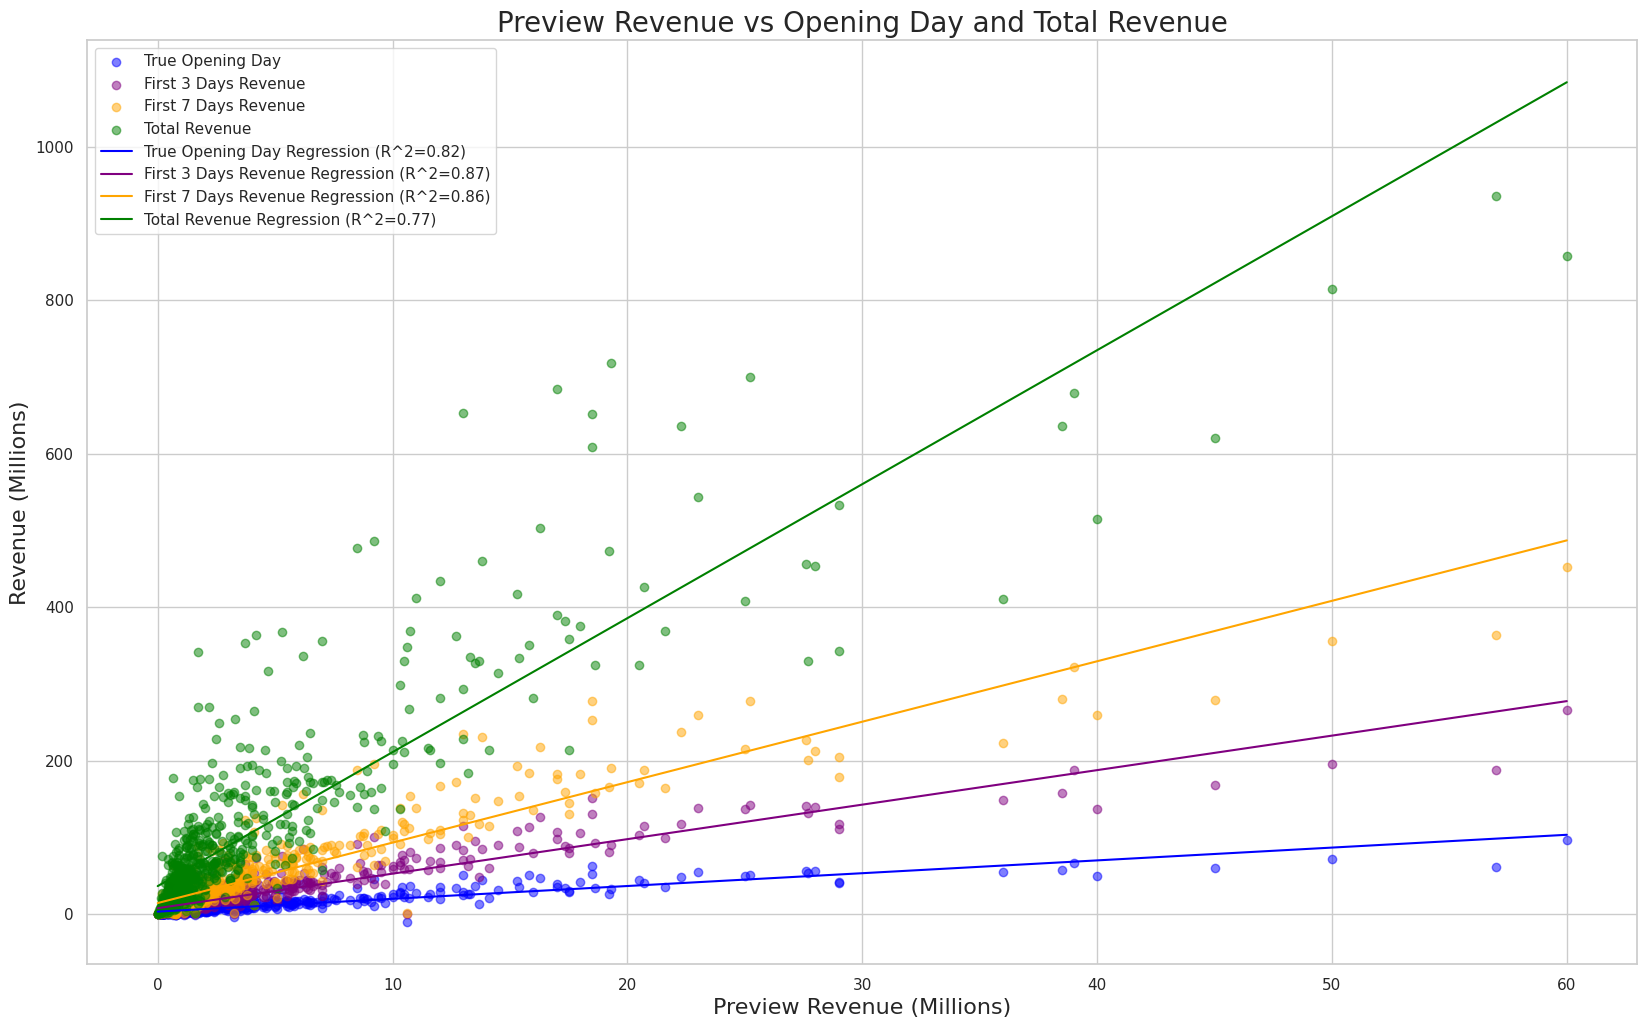

In [36]:
# scatter plot of preview gross to opening day and total revenue

plt.figure(figsize=(20, 12))

plt.scatter(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    [(preview["first_day_revenue"] - preview["preview_revenue"]) / 1_000_000 for preview in previews],
    alpha=0.5,
    label="True Opening Day",
    color="blue",
)
plt.scatter(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    [preview["first_3_days_revenue"] / 1_000_000 for preview in previews],
    alpha=0.5,
    label="First 3 Days Revenue",
    color="purple",
)
plt.scatter(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    [preview["first_7_days_revenue"] / 1_000_000 for preview in previews],
    alpha=0.5,
    label="First 7 Days Revenue",
    color="orange",
)
plt.scatter(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    [preview["total_revenue"] / 1_000_000 for preview in previews],
    alpha=0.5,
    label="Total Revenue",
    color="green",
)

# draw regression lines
x = sm.add_constant([preview["preview_revenue"] for preview in previews])
y = [preview["first_day_revenue"] - preview["preview_revenue"] for preview in previews]
model = sm.OLS(y, x).fit()
plt.plot(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    model.predict(x) / 1_000_000,
    color="blue",
    label=f"True Opening Day Regression (R^2={model.rsquared:.2f})",
)
y = [preview["first_3_days_revenue"] for preview in previews]
model = sm.OLS(y, x).fit()
plt.plot(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    model.predict(x) / 1_000_000,
    color="purple",
    label=f"First 3 Days Revenue Regression (R^2={model.rsquared:.2f})",
)
y = [preview["first_7_days_revenue"] for preview in previews]
model = sm.OLS(y, x).fit()
plt.plot(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    model.predict(x) / 1_000_000,
    color="orange",
    label=f"First 7 Days Revenue Regression (R^2={model.rsquared:.2f})",
)
y = [preview["total_revenue"] for preview in previews]
model = sm.OLS(y, x).fit()
plt.plot(
    [preview["preview_revenue"] / 1_000_000 for preview in previews],
    model.predict(x) / 1_000_000,
    color="green",
    label=f"Total Revenue Regression (R^2={model.rsquared:.2f})",
)

plt.xlabel("Preview Revenue (Millions)", fontsize=16)
plt.ylabel("Revenue (Millions)", fontsize=16)
plt.title("Preview Revenue vs Opening Day and Total Revenue", fontsize=20)
plt.legend()